<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
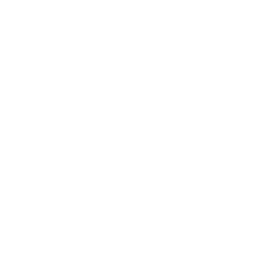
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Análisis de Tendencia EWMA de la Tasa de Errores de Medicación</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Salud / Seguridad del Paciente &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Este análisis monitorea la tasa semanal de errores de medicación en una unidad de cuidados intensivos (UCI) hospitalaria usando un **gráfico de control de media móvil exponencialmente ponderada (EWMA)** de PROC MACONTROL. La UCI implementó un nuevo sistema de registro electrónico de administración de medicamentos (eMAR) en la semana 51 de la ventana de observación. Los equipos de seguridad del paciente necesitan un método de alerta temprana que señale rápidamente un aumento sostenido de errores, antes de que se acumule un trimestre de reportes de daño.

El gráfico EWMA con peso de suavizado **lambda = 0.3** se construye en dos fases. Los límites de control se establecen primero a partir de la línea base estable previa a la migración (semanas 1-50), luego la serie completa de 100 semanas se monitorea contra esos límites fijos. El gráfico se mantiene en control durante toda la línea base y señala una condición fuera de control la **primera semana después de la puesta en marcha**, confirmando que la transición a eMAR coincidió con un cambio real y sostenido en la tasa de errores, y no con el ruido ordinario semana a semana.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|-----------|
| WORK.ICU_ERRORS | Tasa semanal de errores de medicación por 1,000 administraciones para una UCI, 100 semanas consecutivas | 100 |

Se monitorea una única UCI semanalmente. Cada registro contiene el número de semana, la tasa de errores por 1,000 administraciones, el volumen de administraciones y el conteo de errores derivado. Un cambio de proceso documentado (puesta en marcha de eMAR) ocurre en la semana 51, desplazando la media subyacente de la tasa de errores hacia arriba en aproximadamente 1.6 por 1,000.

---

In [1]:
/* --------------------------------------------------------
   Generar datos semanales de errores de medicación de la UCI
   100 semanas consecutivas para una UCI.
   Un nuevo sistema eMAR entra en funcionamiento en la semana 51,
   elevando la tasa de error subyacente de ~3.5 a ~5.1 por 1,000.
   -------------------------------------------------------- */
DATOS work.icu_errors;
    LLAMAR streaminit(42);
    LONGITUD unit_name $12 phase $12;
    unit_name = 'UCI';
    base_rate  = 3.5;   /* tasa media pre-migración / 1,000 */
    unit_sigma = 0.45;  /* ruido semana a semana de causa común */
    HACER week_num = 1 HASTA 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        SI administrations < 300 ENTONCES administrations = 300;
        /* la migración a eMAR desplaza la media hacia arriba tras la semana 50 */
        SI week_num > 50 ENTONCES HACER;
            phase = 'POST-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        END;
        SINO HACER;
            phase = 'REFERENCIA';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        END;
        SI error_rate_per_1k < 0 ENTONCES error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        SALIDA;
    END;
    ELIMINAR base_rate unit_sigma;
    FORMATO week_start_date date9.;
EJECUTAR;


NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                  Tasa de Errores en la UCI: Referencia vs. Post-eMAR                                   

                                                  The MEANS Procedure

                            Analysis Variable : error_rate_per_1k Tasa de Errores por 1,000

        Fase                N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        POST-eMAR              50           5.11           0.44           3.69           5.96
        REFERENCIA             50           3.50           0.48           2.55           4.71
        -------------------------------------------------------------------------------------

                                  Analysis Variable : error_count Cantidad de Errores

        Fase                N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


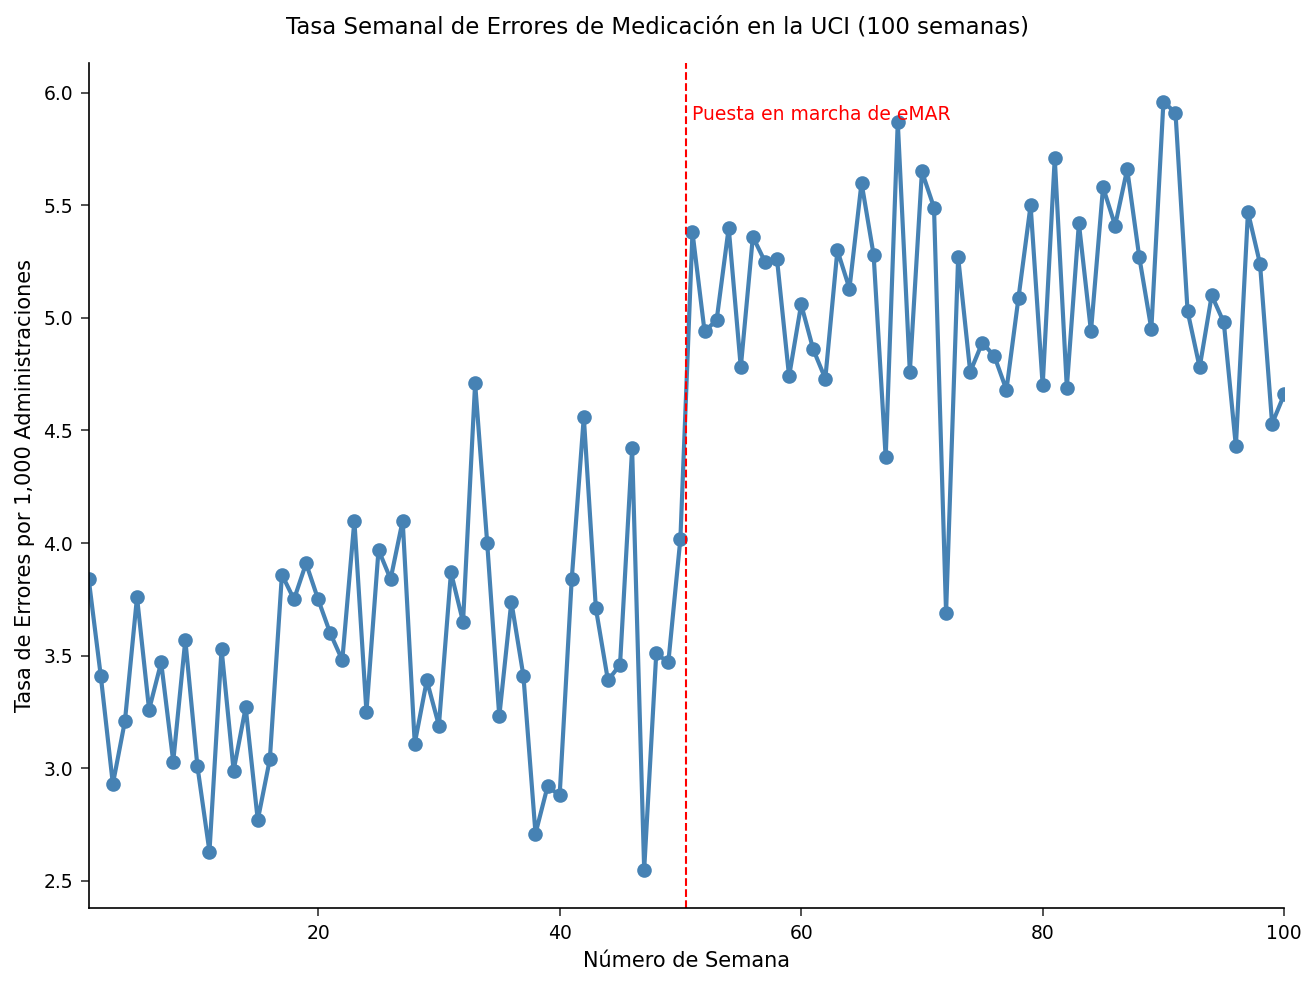

In [2]:
/* --------------------------------------------------------
   Comparar la tasa de errores antes y después de la puesta en
   marcha de eMAR, y graficar la tendencia semanal.
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.icu_errors n mean std MIN MAX maxdec=2;
    CLASE phase;
    VAR error_rate_per_1k error_count administrations;
    ETIQUETA phase='Fase'
             error_rate_per_1k='Tasa de Errores por 1,000'
             error_count='Cantidad de Errores'
             administrations='Administraciones';
    TÍTULO 'Tasa de Errores en la UCI: Referencia vs. Post-eMAR';
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   ETIQUETA='Puesta en marcha de eMAR';
    XAXIS ETIQUETA='Número de Semana';
    YAXIS ETIQUETA='Tasa de Errores por 1,000 Administraciones';
    TÍTULO 'Tasa Semanal de Errores de Medicación en la UCI (100 semanas)';
EJECUTAR;

---

In [3]:
/* --------------------------------------------------------
   Fase I: establecer los límites de control EWMA a partir de la
   línea base estable previa a la migración (semanas 1-50). Estos
   límites fijos son la referencia para todo el período de
   monitoreo.
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.icu_errors(DONDE=(week_num <= 50)) NOPRINT;
    VAR error_rate_per_1k;
    SALIDA out=work.baseline_stats mean=base_mean std=base_std;
EJECUTAR;

DATOS work.icu_limits;
    ESTABLECER work.baseline_stats;
    LONGITUD _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* línea central de referencia */
    _STDDEV_ = base_std;    /* sigma de causa común de referencia */
    _LIMITN_ = 1;
    MANTENER _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.icu_limits noobs label;
    ETIQUETA _VAR_='Variable' _SUBGRP_='Subgrupo'
             _MEAN_='Media' _STDDEV_='Desv. Estándar' _LIMITN_='N Límite';
    TÍTULO 'Entradas de Límites de Control - Fase I (semanas de referencia 1-50)';
EJECUTAR;

                          Entradas de Límites de Control - Fase I (semanas de referencia 1-50)                          

         Variable  Subgrupo   Media   Desv. Estándar   N Límite
error_rate_per_1k  week_num  3.5014     0.4829036749          1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                          Entradas de Límites de Control - Fase I (semanas de referencia 1-50)                          


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/7cb22861-f767-40c3-9614-c0f0ea5fbfd8/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


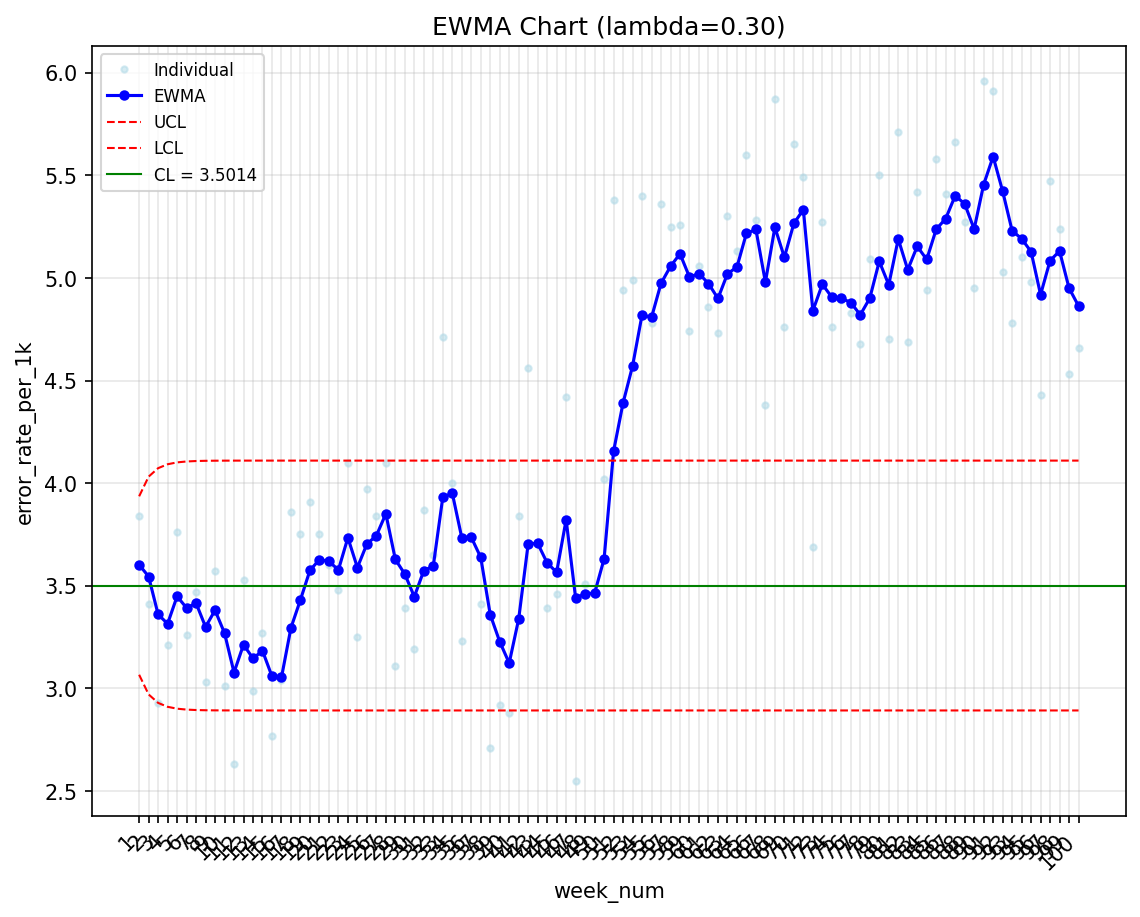

In [4]:
/* --------------------------------------------------------
   Fase II: monitorear la serie completa de 100 semanas contra
   los límites fijos de referencia. lambda=0.3 da una detección
   responsiva adecuada para la vigilancia de seguridad del
   paciente.
   -------------------------------------------------------- */
PROCEDIMIENTO macontrol DATOS=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        PESO    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    ETIQUETA error_rate_per_1k =
          'Errores de Medicación por 1,000 Administraciones';
    TÍTULO 'Gráfico EWMA: Tasa de Errores de Medicación en la UCI (lambda=0.3)';
EJECUTAR;

---

In [5]:
/* --------------------------------------------------------
   Identificar cada semana en que el EWMA supera los límites de
   referencia e informar cuándo señala el gráfico por primera
   vez.
   -------------------------------------------------------- */
DATOS work.signals;
    ESTABLECER work.icu_table;
    DONDE _EXLIM_ ne ' ' AND _EXLIM_ ne '0';
EJECUTAR;

PROCEDIMIENTO SQL;
    SELECCIONAR count(*)        AS n_signals          ETIQUETA='Semanas con Señal',
           MIN(week_num)    AS first_signal_week  ETIQUETA='Primera Semana con Señal',
           MAX(_EWMA_)      AS peak_ewma FORMATO=6.3 ETIQUETA='EWMA Máximo'
    DESDE work.signals;
QUIT;

PROCEDIMIENTO IMPRIMIR DATOS=work.signals(obs=8) label;
    VAR week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    ETIQUETA week_num='Semana' error_rate_per_1k='Tasa de Errores'
             _EWMA_='EWMA' _UCLE_='LCS EWMA' _EXLIM_='Fuera de Límite';
    TÍTULO 'Primeras Señales EWMA Fuera de Control';
EJECUTAR;

                          Entradas de Límites de Control - Fase I (semanas de referencia 1-50)                          

 Semanas con Señal   Primera Semana con Señal   EWMA Máximo
------------------  -------------------------  ------------
                50                       51.0         5.591
                                         Primeras Señales EWMA Fuera de Control                                         

  Obs  Semana      EWMA  LCS EWMA   Fuera de Límite
    1      51  4.155551   4.10998                 1
    2      52  4.390886   4.10998                 1
    3      53   4.57062   4.10998                 1
    4      54  4.819434   4.10998                 1
    5      55  4.807604   4.10998                 1
    6      56  4.973323   4.10998                 1
    7      57  5.056326   4.10998                 1
    8      58  5.117428   4.10998                 1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Interpretación

El análisis EWMA de dos fases separa claramente la variación ordinaria semana a semana del cambio de proceso real en la puesta en marcha de eMAR.

**Línea base (semanas 1-50).** PROC MEANS reporta una tasa media de errores de referencia de **3.50 por 1,000 administraciones** (desviación estándar 0.48), frente a una media post-migración de **5.11** (desviación estándar 0.44) -- un desplazamiento sostenido hacia arriba de aproximadamente **1.6 errores por 1,000**. El volumen de administraciones es comparable entre las dos fases (795 vs 790 por semana), por lo que el cambio refleja la *tasa* de error y no una variación en la carga de trabajo.

**Límites de control.** Los límites se fijan solo a partir de la línea base: línea central **3.5014**, sigma de referencia **0.4829**. Con peso de suavizado lambda = 0.3 y límites de 3-sigma, el límite superior del EWMA se estabiliza en su valor asintótico de aproximadamente **4.11**. Durante las semanas 1-50 el estadístico EWMA se mantiene dentro de estos límites -- la línea base produce **cero falsas alarmas**, confirmando que el gráfico no es demasiado sensible.

**Detección.** El gráfico señala una condición fuera de control en la **primera semana después de la puesta en marcha (semana 51)**, donde el EWMA alcanza **4.156**, apenas por encima del límite de 4.11. A partir de ese punto el estadístico sube de forma constante y permanece por encima del límite superior durante todo el período post-migración: **las 50 semanas post-migración (51-100) señalan**, y el EWMA alcanza un máximo de **5.591** alrededor de la semana 91. La capacidad de respuesta de lambda = 0.3 significa que el deterioro se señala de inmediato en lugar de después de varias semanas de acumulación.

**Acción.** Una ruptura sostenida del EWMA que comienza en la semana de una implementación de eMAR es evidencia sólida de que el nuevo sistema -- y no el azar -- impulsó el aumento. El comité de seguridad del paciente debería tratar la semana 51 como el punto de cambio, auditar los flujos de trabajo de solicitud y anulación de medicamentos de eMAR introducidos esa semana, y mantener el gráfico funcionando contra los límites de referencia originales hasta que el EWMA regrese por debajo de 4.11. Los archivos exportados `icu_ewma_signals.csv` (50 semanas con señal) e `icu_ewma_table.csv` proporcionan el registro de evidencia de SPC documentado para la revisión de preparación continua de la Comisión Conjunta (Joint Commission).

---

In [6]:
/* --------------------------------------------------------
   Exportar la tabla EWMA y la lista de señales para la
   documentación de preparación continua de la Comisión Conjunta
   (Joint Commission).
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>